In [13]:
# This cell is labelled 'paramters' to work with papermill remotely
# Papermill will overwite the default local plate value below with whatever is passed to 
# the -p flag in the snakerule shell script
#os.system("conda activate eqtl_study") use this locally if using VScode
plate = 'plate1'
plate = globals().get("plate")
print(f"Processing plate: {plate}")

Processing plate: plate1


In [14]:
# Import custom utility packages, lists and functions
import sys
import os
if os.path.exists('/scratch/'):
    root_dir = '/scratch/c.c1477909/eQTL_study_2025/'
else:
    root_dir = '/Users/darren/Desktop/eQTL_study_2025/'
        
sys.path.append(root_dir + 'workflow/scripts/')

from init_env import *
from anndata_utils import *
from gene_lists import *

# Set variables
resolutions = [0.1] 

2025-03-04 14:02:16,875 - INFO - Plate variable detected: plate1
2025-03-04 14:02:16,876 - INFO - Processing plate: plate1



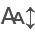

2025-03-04 14:02:16,894 - INFO - Script initialized. Root directory: /Users/darren/Desktop/eQTL_study_2025/
2025-03-04 14:02:16,895 - INFO - Parse directory: /Users/darren/Desktop/eQTL_study_2025/results/02PARSE/
2025-03-04 14:02:16,896 - INFO - Scanpy directory: /Users/darren/Desktop/eQTL_study_2025/results/03SCANPY/
2025-03-04 14:02:16,896 - INFO - Scanpy directory exists: True
2025-03-04 14:02:16,897 - INFO - Sheets directory: /Users/darren/Desktop/eQTL_study_2025/resources/sheets/
2025-03-04 14:02:16,901 - INFO - plate_dir set to: /Users/darren/Desktop/eQTL_study_2025/results/02PARSE/combine_plate1/all-sample/DGE_filtered/
2025-03-04 14:02:16,902 - INFO - Loading data ...


In [15]:
# Initialize the environment and get all paths and logger
logger, root_dir, sheets_dir, plate_path, scanpy_dir = initialize_env(plate)
logger.info("Loading data ...")
adata = sc.read(scanpy_dir + f'adata_clusters.h5ad')

In [16]:
# Get Sex
# Define sex-specific genes (adjust based on your dataset/species)
sex_genes = ["XIST", "RPS4Y1", "DDX3Y"]

# Check if genes are present in the dataset
sex_genes = [gene for gene in sex_genes if gene in adata.var_names]
print(sex_genes)
# Plot expression levels
sc.pl.violin(adata, keys=sex_genes, groupby="leiden_harmony_0.1") 

[]


ZeroDivisionError: float division by zero

In [17]:
# Aggregate expression per donor/sample
sex_gene_exp = adata[:, sex_genes].X.mean(axis=0)  # Averaging across cells
sex_gene_df = pd.DataFrame(sex_gene_exp, index=sex_genes, columns=["Mean Expression"])

print(sex_gene_df)

Empty DataFrame
Columns: [Mean Expression]
Index: []


In [18]:
logger.info(f"Creating UMAP with cell types ...")
cluster_anns = {
    
    '0': 'RG',
    '1': 'ExN-1',
    '2': 'InN-1',
    '3': 'ExN-2',
    '4': 'InN-2',
    '5': 'Endo-Peri',
    '6': 'MG',
    '7': 'Mig-N',
}

custom_palette = {
    'RG': '#FF5959',        # Red
    'ExN-1': '#00B6EB',     # Cyan
    'ExN-2': '#1E90FF',     # Blue
    'InN-1': '#32CD32',     # Lime Green
    'InN-2': '#00FF00',     # Neon Green
    'Endo-Peri': '#FF00FF', # Magenta
    'MG': '#FFA500',        # Orange
    'Mig-N': '#FFFF00'      # Yellow
}

# Create a new column in adata.obs with cell type names
adata.obs['cell_type'] = adata.obs['leiden_harmony_0.1'].map(cluster_anns)

2025-03-04 14:02:49,113 - INFO - Creating UMAP with cell types ...


In [19]:
adata

AnnData object with n_obs × n_vars = 7340 × 1724
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'sublibrary', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'doublet_score', 'predicted_doublet', 'leiden', 'mito_gt_threshold', 'ribo_gt_threshold', 'is_outlier', 'plate', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_harmony_0.1', 'leiden_harmony_0.2', 'leiden_harmony_0.3', 'cell_type'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std'
    

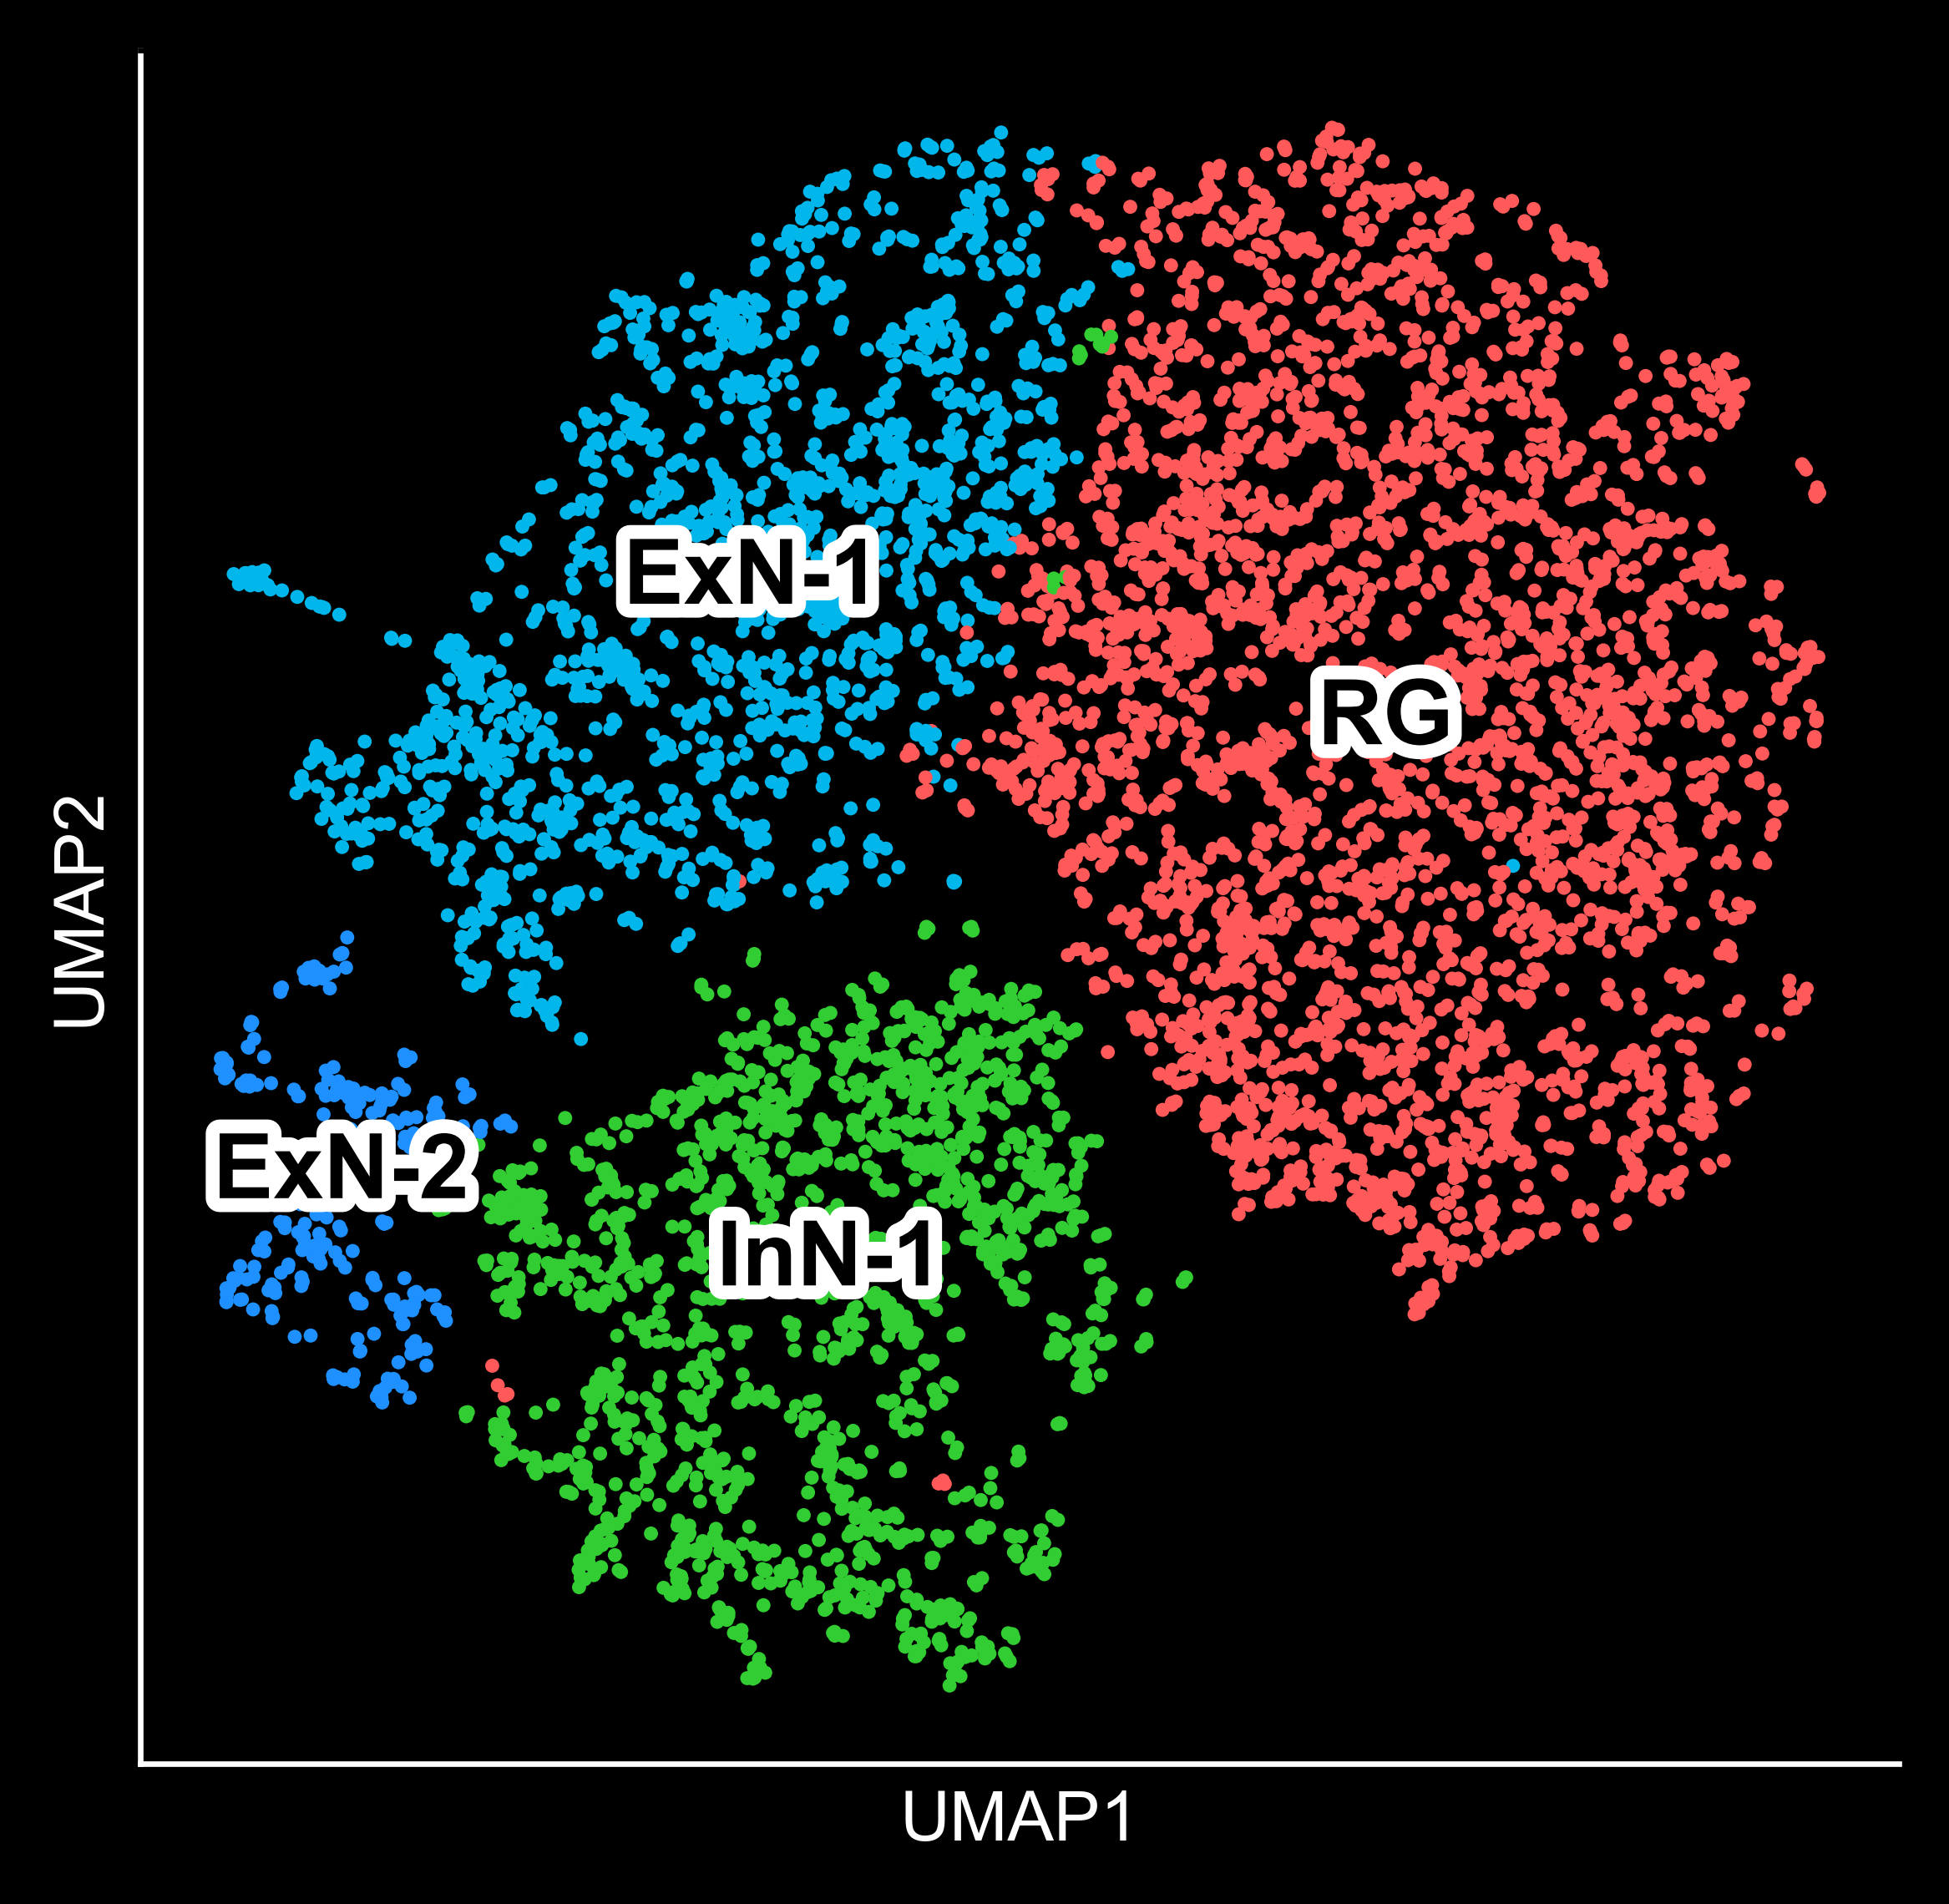

In [20]:
fig, ax = plt.subplots(figsize=(4.5, 4.5), dpi=300)  # Increase dpi for high resolution

# Black background settings
ax.set_facecolor("black")
fig.patch.set_facecolor("black")

# UMAP Plot with custom colors
sc.pl.umap(
    adata, 
    legend_loc="on data",
    legend_fontsize=13,
    legend_fontoutline=4,
    color="cell_type",  # Change to the desired column in adata.obs
    title='',
    ax=ax,
    show=False,
    palette=custom_palette
)

# Update axis colors to white
ax.spines["bottom"].set_color("white")
ax.spines["left"].set_color("white")
ax.xaxis.label.set_color("white")
ax.yaxis.label.set_color("white")
ax.tick_params(colors="white")

# Show plot
plt.show()

KeyError: "Could not find keys '['C3', 'COL4A1', 'CSF1R', 'DLX6-AS1', 'EBF3', 'FN1', 'GAD1', 'INPP5D', 'SLC1A3']' in columns of `adata.obs` or in adata.raw.var_names."

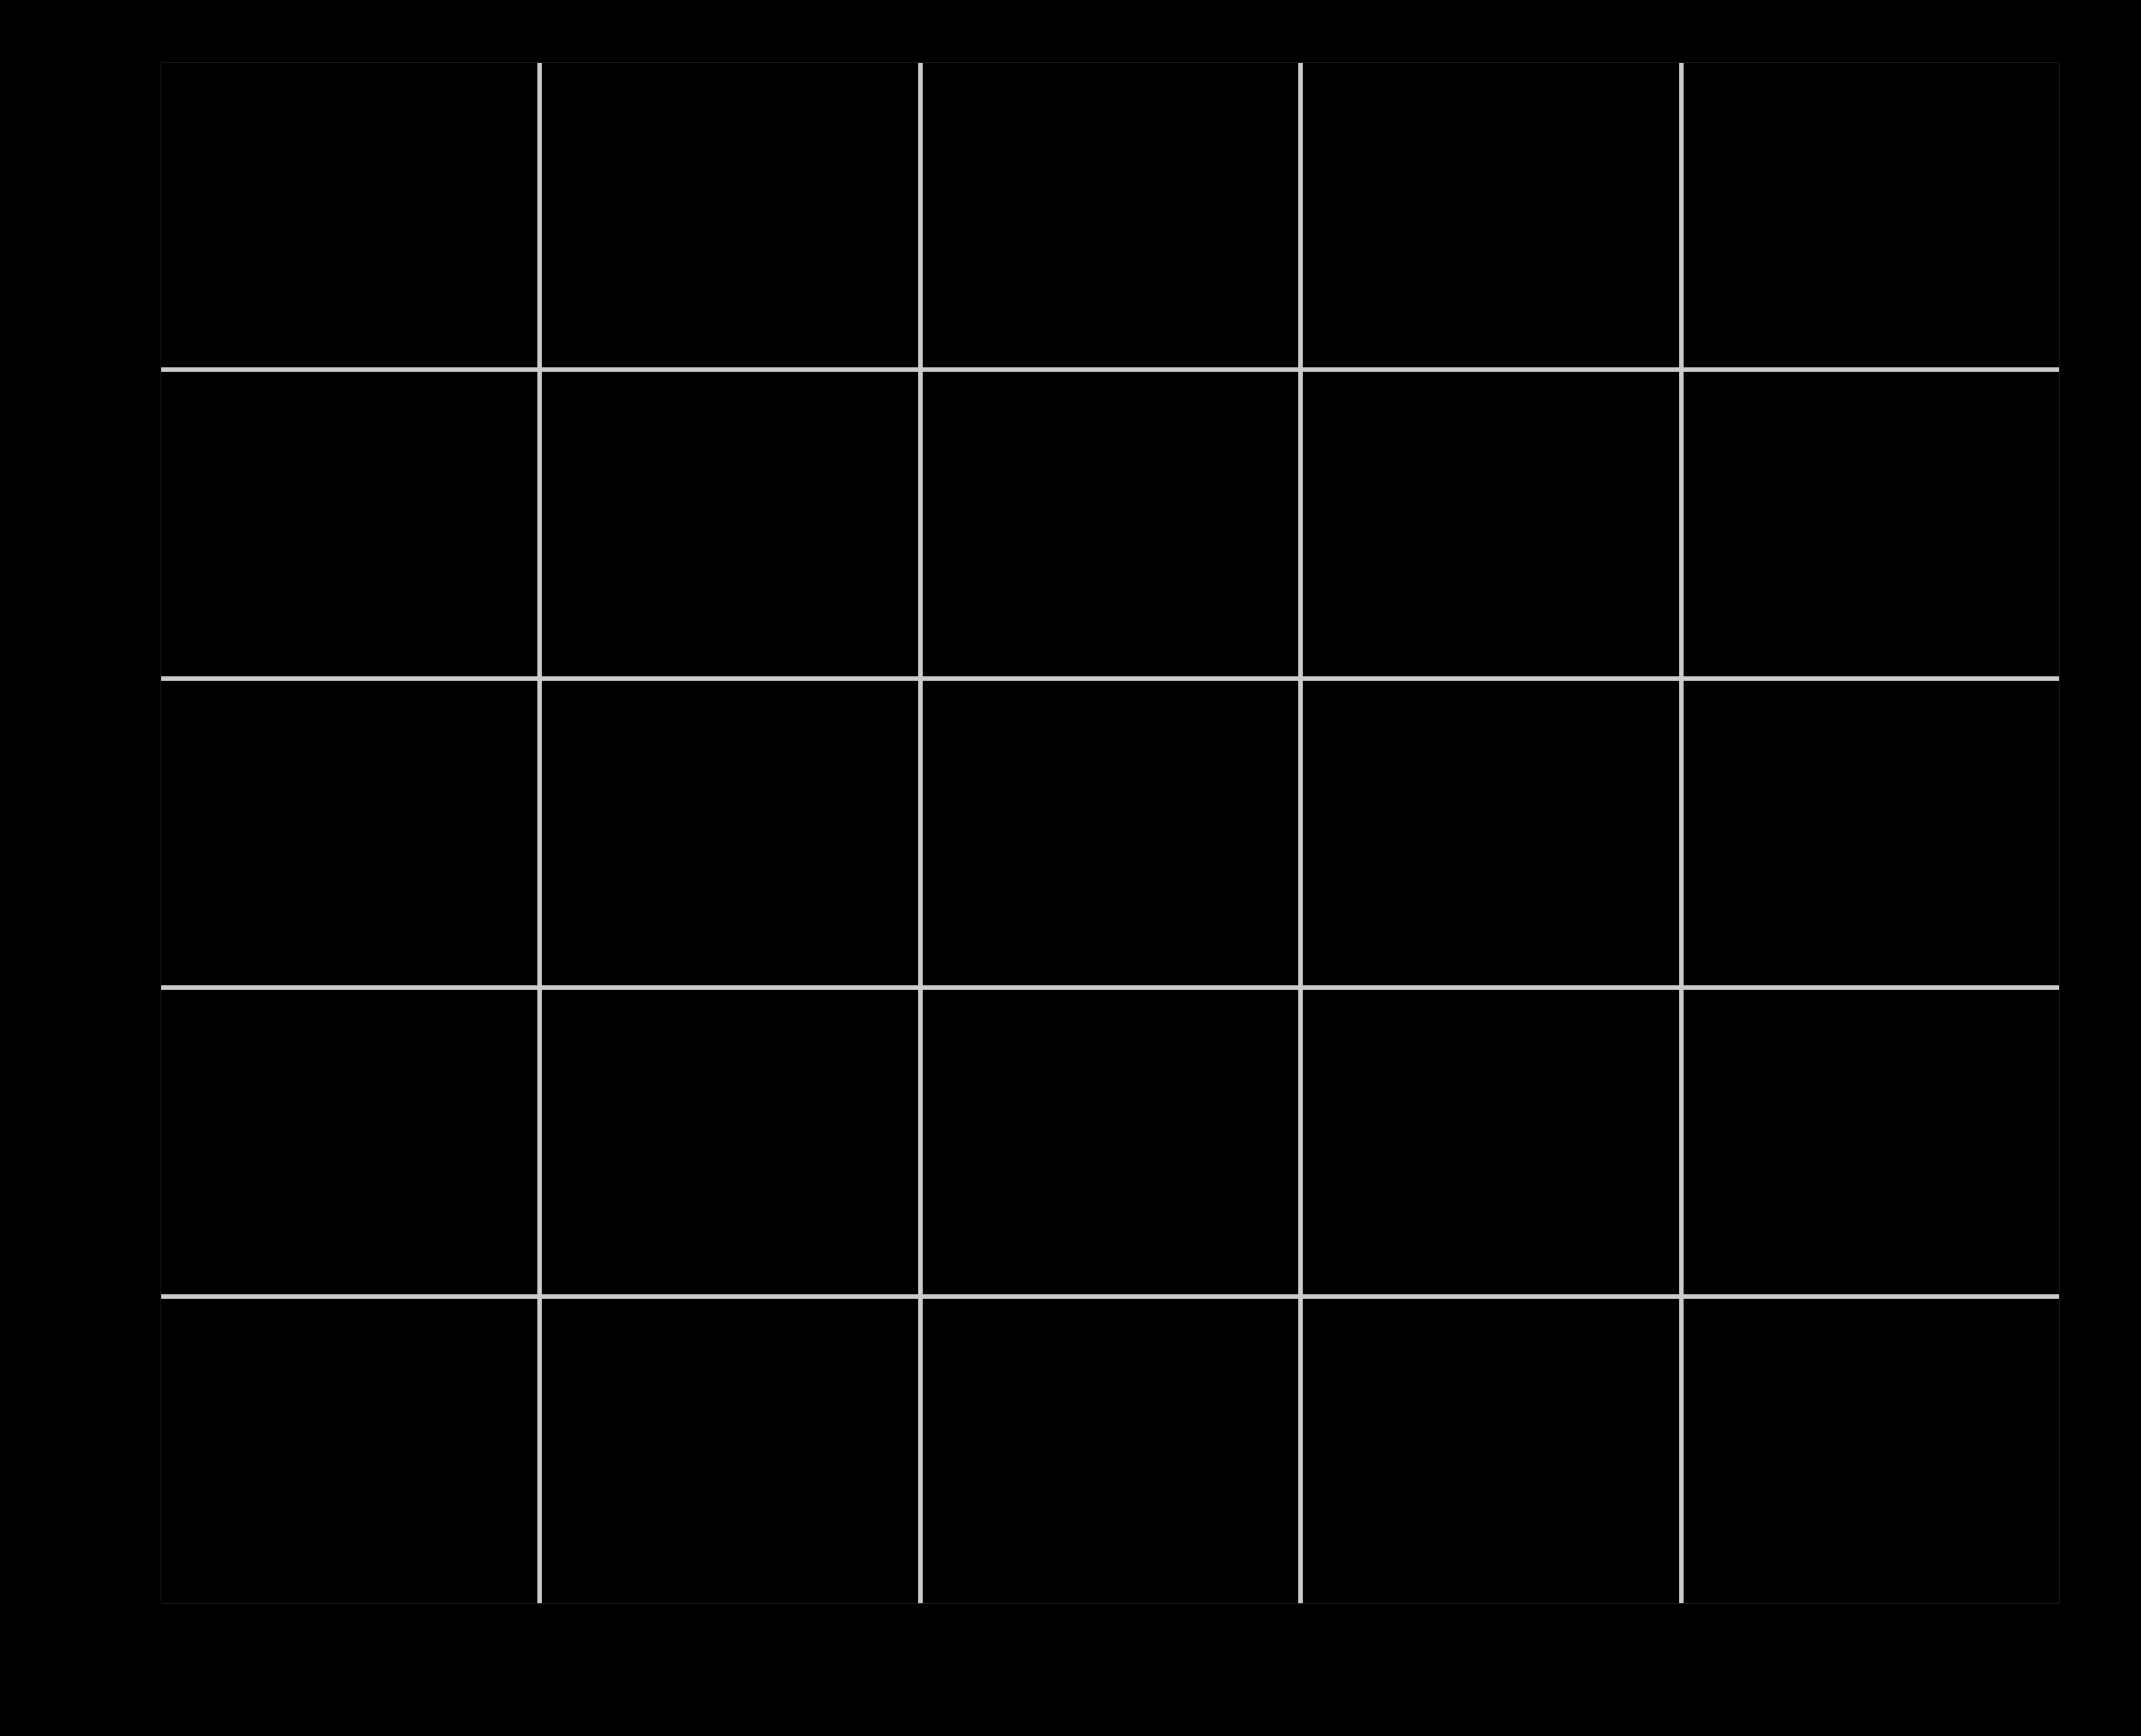

In [ ]:
# # Final Markers
# marker_genes_dict = {
#     'RG': ['GLI3', 'SLC1A3'],
#     'ExN-1': ['SATB2'],
#     'InN-1': ['NRXN3', 'CNTNAP2'],
#     'ExN-2': ['GRIK3', 'GAS7'],
#     'InN-2': ['GAD1', 'SOX6', 'DLX6-AS1', 'ERBB4'],
#     'Endo-Peri': ['FN1', 'COL4A1'],
#     'MG': ['C3', 'INPP5D', 'CSF1R'],
#     'Mig-N': ['EBF3']
# }

# custom_palette = [
#     '#FF9999',  # RG
#     '#66CCCC',  # ExN-1
#     '#FFCC99',  # InN-1
#     '#99CCFF',  # ExN-2
#     '#FF99CC',  # InN-2
#     '#CCFF99',  # Endo-Peri
#     '#CCCCFF',  # MG
#     '#FFFF99'   # Mig-N
# ]

# fig, ax = plt.subplots(figsize=(6, 5), dpi=300)  # Adjust figsize as needed

# # Black background settings
# ax.set_facecolor("black")
# fig.patch.set_facecolor("black")

# # Stacked violin plot
# sc.pl.stacked_violin(
#     adata,
#     var_names=marker_genes_dict,  # Your gene dictionary
#     groupby="cell_type",          # Matches the column used in your UMAP
#     ax=ax,
#     show=False,                   # Prevents automatic display
#     palette=custom_palette,       # Reuse your custom UMAP palette
#     standard_scale="var",         # Optional: scales each gene independently
#     dendrogram=False,             # Set to True if you want a dendrogram
#     swap_axes=False               # Set to True if you prefer genes on x-axis
# )

# # Update axis colors to white for contrast
# ax.spines["bottom"].set_color("white")
# ax.spines["top"].set_color("white")
# ax.spines["left"].set_color("white")
# ax.spines["right"].set_color("white")
# ax.xaxis.label.set_color("white")
# ax.yaxis.label.set_color("white")
# ax.tick_params(colors="white", which="both")  # Includes minor ticks
# ax.title.set_color("white")                   # If a title is added later

# # Adjust fonts for publication quality (optional)
# ax.tick_params(labelsize=12)  # Adjust tick label size
# ax.xaxis.label.set_size(14)   # Adjust x-axis label size
# ax.yaxis.label.set_size(14)   # Adjust y-axis label size

# # Show the plot
# plt.tight_layout()  # Ensures proper spacing
# plt.show()